In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip


--2025-04-14 12:55:49--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-04-14 12:55:50--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-04-14 12:55:50--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
!pip install tensorflow scikit-learn pandas numpy


In [ ]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
import matplotlib.pyplot as plt


nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2

In [ ]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv('/content/WELFake_Dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (72134, 4)


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')
df['content'] = df['title'] + ' ' + df['text']

In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'<.*?>+', '', text)  # Remove HTML tags
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\n', ' ', text)  # Remove line breaks
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    text = ' '.join([word for word in text.split() if word not in stop_words and len(word) > 2])
    return text

In [ ]:
df['clean_content'] = df['content'].apply(clean_text)
print("Label distribution:")
print(df['label'].value_counts())

Label distribution:
label
1    37106
0    35028
Name: count, dtype: int64


In [ ]:
X = df['clean_content']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
max_words = 15000  
max_len = 200      

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

In [ ]:
embedding_dim = 100
embedding_index = {}

with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs


In [ ]:
embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < max_words:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector


In [ ]:
model = Sequential([
    Embedding(max_words, embedding_dim,
              weights=[embedding_matrix],
              input_length=max_len,
              trainable=True),

    SpatialDropout1D(0.3),

    Bidirectional(LSTM(128, return_sequences=True,
                  kernel_regularizer=l2(0.01))),

    Bidirectional(LSTM(64)),

    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,000 (5.72 MB)

 Trainable params: 1,500,000 (5.72 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [EarlyStopping(patience=2, monitor='val_accuracy', mode='max', restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)]

In [ ]:
history = model.fit(
    X_train_seq, y_train,
    batch_size=128,
    epochs=8,  # Reduced from 15
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
360/361 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7986 - loss: 1.3667

361/361 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.7989 - loss: 1.3630 - val_accuracy: 0.9128 - val_loss: 0.2675
Epoch 2/8
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9048 - loss: 0.2787

361/361 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.9048 - loss: 0.2787 - val_accuracy: 0.9236 - val_loss: 0.2710
Epoch 3/8
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9235 - loss: 0.2502

361/361 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.9235 - loss: 0.2501 - val_accuracy: 0.9329 - val_loss: 0.1999
Epoch 4/8
360/361 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9444 - loss: 0.1795

361/361 ━━━━━━━━━━━━━━━━━━━━ 42s 63ms/step - accuracy: 0.9444 - loss: 0.1794 - val_accuracy: 0.9491 - val_loss: 0.1611
Epoch 5/8
360/361 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9589 - loss: 0.1358

361/361 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.9589 - loss: 0.1358 - val_accuracy: 0.9516 - val_loss: 0.1613
Epoch 6/8
360/361 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9675 - loss: 0.1117

361/361 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.9675 - loss: 0.1117 - val_accuracy: 0.9586 - val_loss: 0.1327
Epoch 7/8
360/361 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9756 - loss: 0.0915

361/361 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.9756 - loss: 0.0916 - val_accuracy: 0.9629 - val_loss: 0.1259
Epoch 8/8
360/361 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9785 - loss: 0.0801

361/361 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.9785 - loss: 0.0801 - val_accuracy: 0.9653 - val_loss: 0.1239


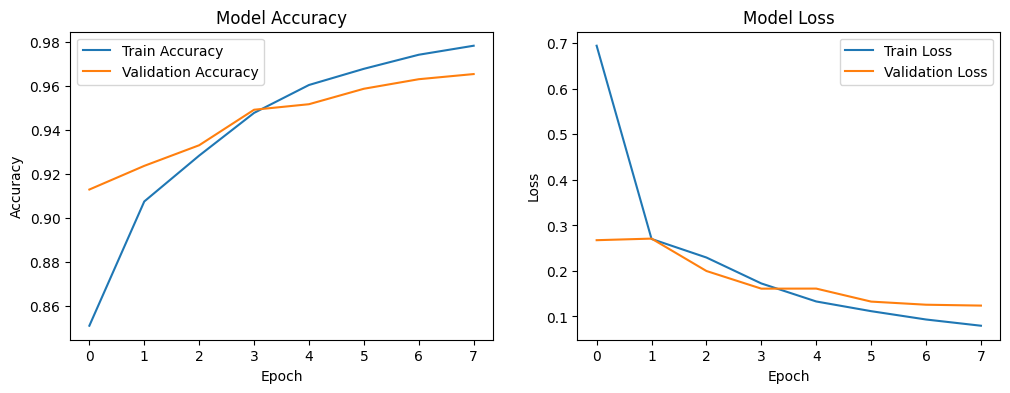

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test_seq, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

451/451 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9611 - loss: 0.1410
Test Accuracy: 0.9630


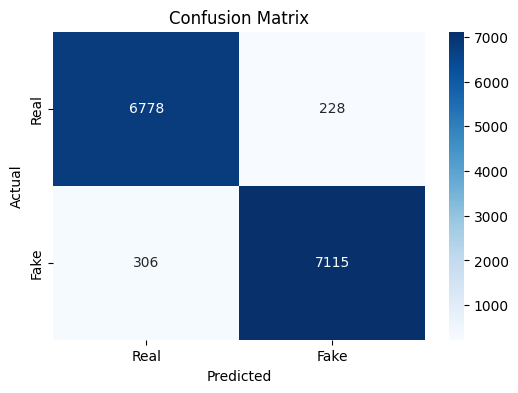

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
y_pred = (model.predict(X_test_seq) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


451/451 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      7006
           1       0.97      0.96      0.96      7421

    accuracy                           0.96     14427
   macro avg       0.96      0.96      0.96     14427
weighted avg       0.96      0.96      0.96     14427



Fake News-Detection Using KNN Model


Dataset Sample:
   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
Model Accuracy: 0.7656


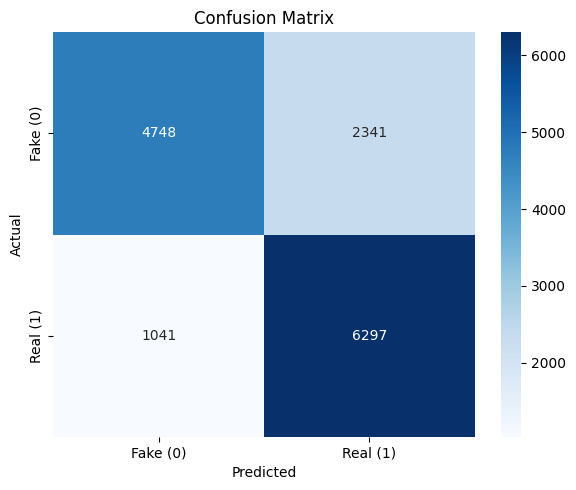

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


df = pd.read_csv('/content/WELFake_Dataset.csv')  
print("Dataset Sample:")
print(df.head())


assert 'title' in df.columns and 'text' in df.columns and 'label' in df.columns, "Required columns missing in the dataset."

df['combined_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')


X_train, X_test, y_train, y_test = train_test_split(
    df['combined_text'], df['label'], test_size=0.2, random_state=42
)


tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_tfidf, y_train)


y_pred = knn_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake (0)', 'Real (1)'],
            yticklabels=['Fake (0)', 'Real (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()